## EDA for presentation

## Setup
Import libraries and connect to the USDA and Open Food Facts DuckDB databases.

In [85]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt

In [86]:
# import the off.duckdb and usda.duckdb databases
con = duckdb.connect('usda.duckdb')
con2 = duckdb.connect('off.duckdb')


In [ ]:
off = con2.execute('SELECT * FROM nutrition_minimal').fetchdf()
off.rename(columns={"product_name": "description"}, inplace=True)
off = off.dropna(subset=["description"])

## 1. USDA — Join Food Tables
Query the USDA DuckDB database to join `food`, `food_category`, `usda_macros`, and `food_portion` on `fdc_id`. Drop rows missing any of the four macronutrients.

In [88]:
# join the schemas: food, usda_macros, food_category, food_portion on fdc_id
usda = con.execute("""
    SELECT
        f.fdc_id,
        f.description,
        f.data_type,
        f.publication_date,
        fc.description   AS category,
        um.kcal_100g,
        um.protein_100g,
        um.carbs_100g,
        um.fat_100g,
        fp.gram_weight,
        fp.portion_description,
        fp.amount,
        fp.modifier
    FROM food f
    LEFT JOIN food_category fc
        ON f.food_category_id = fc.id
    LEFT JOIN usda_macros um
        ON CAST(f.fdc_id AS BIGINT) = um.fdc_id
    LEFT JOIN food_portion fp
        ON f.fdc_id = fp.fdc_id
""").fetchdf()

usda.head()

,fdc_id,description,data_type,publication_date,category,kcal_100g,protein_100g,carbs_100g,fat_100g,gram_weight,portion_description,amount,modifier
0,411840,NONFAT CHOCOLATE MILK,branded_food,2019-04-01,NaN,59.0,3.39,11.02,0.00,NaN,NaN,NaN,NaN
1,411841,FRESH HALF & HALF MILK,branded_food,2019-04-01,NaN,117.0,3.33,3.33,10.00,NaN,NaN,NaN,NaN
2,411842,2% REDUCED FAT MILK,branded_food,2019-04-01,NaN,55.0,3.81,5.08,2.12,NaN,NaN,NaN,NaN
3,411843,"ALESSI, PREMIUM GINGER INFUSED WHITE BALSAMIC ...",branded_food,2019-04-01,NaN,133.0,0.00,33.33,0.00,NaN,NaN,NaN,NaN
4,411844,"ALESSI, RED WINE VINEGAR",branded_food,2019-04-01,NaN,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN


In [ ]:
usda.info()
usda.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2117268 entries, 0 to 2117267
Data columns (total 13 columns):
 #   Column               Dtype  
---  ------               -----  
 0   fdc_id               str    
 1   description          str    
 2   data_type            str    
 3   publication_date     str    
 4   category             str    
 5   kcal_100g            float64
 6   protein_100g         float64
 7   carbs_100g           float64
 8   fat_100g             float64
 9   gram_weight          str    
 10  portion_description  str    
 11  amount               str    
 12  modifier             str    
dtypes: float64(4), str(9)
memory usage: 210.0 MB


fdc_id                       0
description                  9
data_type                    0
publication_date             0
category               2019982
kcal_100g               223746
protein_100g            200838
carbs_100g              210786
fat_100g                219281
gram_weight            2070095
portion_description    2095221
amount                 2092141
modifier               2072059
dtype: int64

In [91]:
# pick only the rows where the entries for kcal_100g, protein_100g, carbs_100g, fat_100g are not null
usda = usda.dropna(subset=["kcal_100g", "protein_100g", "carbs_100g", "fat_100g"])

## 2. Food Description Word Counts
Combine USDA and OFF into one dataframe and analyse word count distributions in food descriptions.

In [94]:
# merge the two dataframes without a matching key, just to see how many rows we get
combined = pd.concat([usda, off], ignore_index=True)
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 1917384 entries, 0 to 1917383
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   fdc_id               str    
 1   description          str    
 2   data_type            str    
 3   publication_date     str    
 4   category             str    
 5   kcal_100g            float64
 6   protein_100g         float64
 7   carbs_100g           float64
 8   fat_100g             float64
 9   gram_weight          str    
 10  portion_description  str    
 11  amount               str    
 12  modifier             str    
 13  code                 str    
 14  brands               str    
 15  quantity             str    
 16  serving_size         str    
 17  sugars_100g          float64
 18  fiber_100g           float64
 19  salt_100g            float64
 20  saturated_fat_100g   float64
dtypes: float64(8), str(13)
memory usage: 307.2 MB


In [95]:
combined['word_count'] = combined['description'].str.count(' ') + 1

print(combined['word_count'].value_counts().to_string())

word_count
3.0      295418
4.0      289838
5.0      265947
6.0      212032
2.0      205081
7.0      164909
8.0      116939
9.0       85786
10.0      58717
11.0      43094
1.0       39920
12.0      30416
13.0      23025
14.0      16668
15.0      12655
16.0      10109
17.0       8782
18.0       6558
19.0       5717
20.0       4601
21.0       3842
22.0       2990
23.0       2514
24.0       2240
25.0       1590
26.0       1317
27.0       1151
28.0        928
29.0        701
30.0        590
31.0        486
32.0        405
33.0        302
34.0        293
38.0        280
35.0        213
36.0        202
40.0        147
37.0        141
39.0        110
42.0        103
62.0         64
46.0         61
41.0         60
43.0         44
50.0         41
48.0         40
52.0         37
49.0         34
51.0         31
54.0         26
47.0         24
44.0         21
69.0         17
55.0         14
56.0         14
71.0         12
45.0         11
60.0         11
67.0         11
63.0         11
68.0         

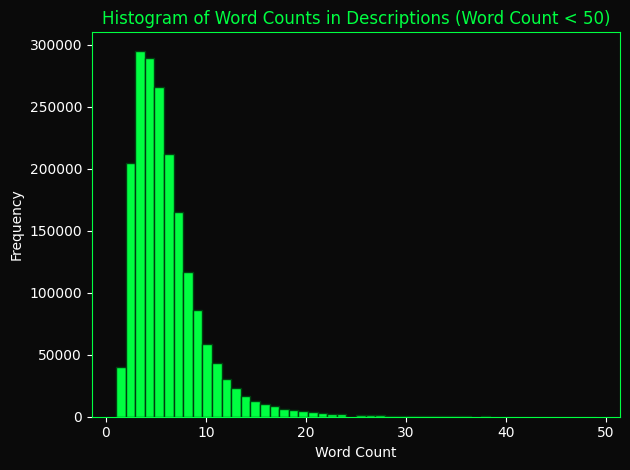

In [96]:
# make a binned historgram of the word counts for word_counts < 50
fig, ax = plt.subplots(facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')
ax.hist(combined[combined['word_count'] < 50]['word_count'], bins=50, color='#00ff41', edgecolor='#003f10')
ax.set_xlabel('Word Count', color='white')
ax.set_ylabel('Frequency', color='white')
ax.set_title('Histogram of Word Counts in Descriptions (Word Count < 50)', color='#00ff41')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#00ff41')
plt.tight_layout()
plt.show()

## 3. Category Word Counts
Load the category-enriched CSVs (`usda_data_cats.csv`, `off_data_cats.csv`), combine them, and analyse word count distributions in category labels.

In [98]:
off_clean = pd.read_csv('old/off_data_cats.csv')
usda_clean = pd.read_csv('old/usda_data_cats.csv')

In [101]:
combined_clean = pd.concat([usda_clean, off_clean], ignore_index=True)

In [102]:
combined_clean['word_count_cats'] = combined_clean['category'].str.count(' ') + 1

print(combined_clean['word_count_cats'].value_counts().to_string())

word_count_cats
1.0      424265
4.0      330371
5.0      303528
3.0      271277
2.0      262115
6.0      173025
8.0       37872
7.0       23688
11.0        118
29.0         65
14.0         53
13.0         40
75.0         25
40.0         19
9.0          17
98.0         14
109.0        12
32.0         11
74.0         10
42.0          6
93.0          6
50.0          5
94.0          5
63.0          5
39.0          4
89.0          4
43.0          3
12.0          3
90.0          2
30.0          1
72.0          1
67.0          1
83.0          1
76.0          1


In [103]:
category_word_counts = (
    combined_clean[['category', 'word_count_cats']]
    .drop_duplicates(subset='category')
    .reset_index(drop=True)
)

category_word_counts

,category,word_count_cats
0,Oils Edible,2.0
1,Herbs/Spices/Extracts,1.0
2,Prepared Soups,2.0
3,Sauces/Spreads/Dips/Condiments,1.0
4,Dough Based Products / Meals,5.0
...,...,...
625,Nutritional beverages,2.0
626,Protein and nutritional powders,4.0
627,Sport and energy drinks,4.0
628,Diet sport and energy drinks,5.0


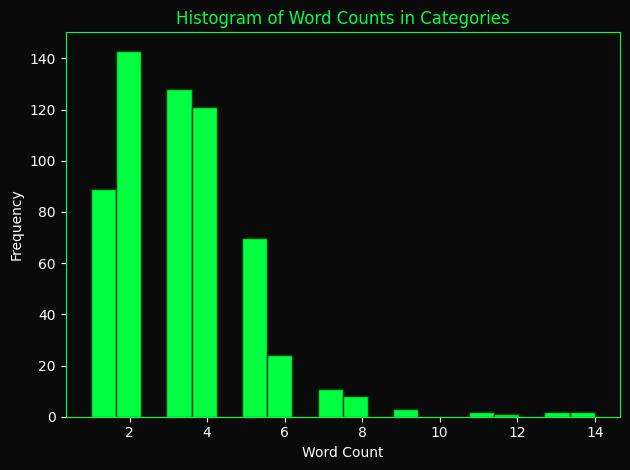

In [104]:
# plot a histogram of the word counts for the categories with word_count_cats < 20
fig, ax = plt.subplots(facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')
ax.hist(category_word_counts[category_word_counts['word_count_cats'] < 20]['word_count_cats'], bins=20, color='#00ff41', edgecolor='#003f10')
ax.set_xlabel('Word Count', color='white')
ax.set_ylabel('Frequency', color='white')
ax.set_title('Histogram of Word Counts in Categories', color='#00ff41')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#00ff41')
plt.tight_layout()
plt.show()

## 4. Merged Category Column
Coalesce USDA's `category` and OFF's `categories_en` into a single `category` column. Build one row per unique category and re-profile word count distributions.

In [108]:
# coalesce: use 'category' where available, fall back to 'categories_en'
combined_clean['category'] = combined_clean['category'].fillna(combined_clean['categories_en'])

# one row per unique category with its word count
category_word_counts = (
    combined_clean['category']
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
    .to_frame(name='category')
)
category_word_counts['word_count_cat'] = category_word_counts['category'].str.split().str.len()

print(f"{len(category_word_counts)} unique categories")
category_word_counts

12560 unique categories


,category,word_count_cat
0,Oils Edible,2
1,Herbs/Spices/Extracts,1
2,Prepared Soups,2
3,Sauces/Spreads/Dips/Condiments,1
4,Dough Based Products / Meals,5
...,...,...
12555,"Plant-based foods and beverages,Plant-based fo...",14
12556,"Snacks,Sweet snacks,Cocoa and its products,Con...",6
12557,"Beverages and beverages preparations,Beverage ...",6
12558,"Beverages and beverages preparations,Plant-bas...",17


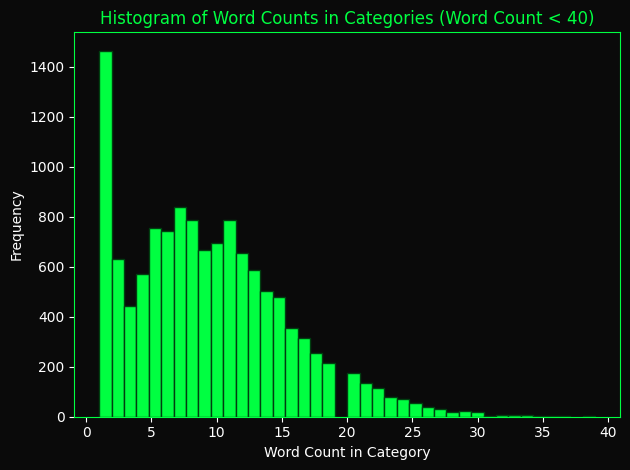

In [109]:
# histogram with category and word_count_cat < 40 columns
fig, ax = plt.subplots(facecolor='#0a0a0a')
ax.set_facecolor('#0a0a0a')
ax.hist(category_word_counts[category_word_counts['word_count_cat'] < 40]['word_count_cat'], bins=40, color='#00ff41', edgecolor='#003f10')
ax.set_xlabel('Word Count in Category', color='white')
ax.set_ylabel('Frequency', color='white')
ax.set_title('Histogram of Word Counts in Categories (Word Count < 40)', color='#00ff41')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#00ff41')
plt.tight_layout()
plt.show()